# Phase 3: Graph and density construction

For right now, I will be using the clipped dataset with $\varepsilon=160$. I will likely change this in the future, but I want to get on with this part of the brief and I will go back to Phase 2 after discussing with you.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import kneighbors_graph
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import connected_components, shortest_path
from scipy.sparse import csr_matrix
import itertools

### Loading data from Phase 1

In [73]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

In [74]:
df = pd.read_parquet("./datasets/observation_df.parquet")
df = df.clip(-3, 3); Z = df.to_numpy()[:, :-1]; N = Z.shape[0]
dates = df.index; variables = df.columns
diff = diffusion_map(Z, eps=160, k=8); Psi = diff["Psi"]

### Task 3.1 - 3.2

In [75]:

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999:
            return None
        path.append(current)
    return path[::-1]

def knn_graph_checks(Psi, k, sample_skip=5):
    N = Psi.shape[0]

    A_dist = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
    A_bin = kneighbors_graph(Psi, n_neighbors=k, mode="connectivity", include_self=False)

    A_dist_sym = A_dist.maximum(A_dist.T); A_bin_sym = A_bin.maximum(A_bin.T)
    n_components, _ = connected_components(A_bin_sym, directed=False)
    degree = np.asarray(A_bin_sym.sum(axis=1)).ravel()
    edges = A_bin_sym.nnz / 2; max_edges = N * (N - 1) / 2; density = edges / max_edges
    graph_edge_lengths = A_dist_sym.data
    _, pred = shortest_path(A_dist_sym, directed=False, unweighted=False, return_predecessors=True)
    jump_ratios = []
    
    for i in range(1, N, sample_skip):
        for j in range(i+1, N, sample_skip):
            path = reconstruct_path(pred, i, j)
            path_edge_lengths = np.array([A_dist_sym[path[i], path[i+1]] for i in range(len(path)-1)])
            med = np.median(path_edge_lengths)
            if med > 1e-12:
                jump_ratios.append(path_edge_lengths.max() / med)

    jump_ratios = np.array(jump_ratios)

    return {
        "k": k,
        "connected_components": n_components,
        "mean_degree": degree.mean(),
        "degree_std": degree.std(),
        "density": density,
        "max_edge_length": np.max(graph_edge_lengths),
        "median_edge_length": np.median(graph_edge_lengths),
        "median_jump_ratio": np.median(jump_ratios),
        "95%_jump_ratio": np.quantile(jump_ratios, 0.95),
        "max_jump_ratio": np.max(jump_ratios)
    }

Jump ratio is the ratio between the maximum distance between nodes to the median distance between nodes in a given shortest path. I calculate a sample of shortest paths for each adjacency matrix.

In [76]:
Psi = diff["Psi"]; ks = [5, 10, 15, 20, 30]
rows = []; jr_rows = []

for k in ks:
    row = knn_graph_checks(Psi, k)
    rows.append(row)
    
graph_df = pd.DataFrame(rows); graph_df.set_index("k", inplace=True)
graph_df["status"] = "Accepted"
display(graph_df)

,connected_components,mean_degree,degree_std,density,max_edge_length,median_edge_length,median_jump_ratio,95%_jump_ratio,max_jump_ratio,status
k,,,,,,,,,,
5,1,7.272244,1.734422,0.009671,0.577247,0.033421,1.407863,3.063353,14.213455,Accepted
10,1,14.462151,2.994278,0.019232,0.625195,0.037644,1.366462,2.807085,13.808655,Accepted
15,1,21.630810,4.357736,0.028764,0.639341,0.040407,1.335948,2.826204,14.643133,Accepted
20,1,28.733068,5.874218,0.038209,0.649072,0.042771,1.319865,2.793492,13.562871,Accepted
30,1,43.059761,9.080890,0.057260,0.660614,0.046381,1.295000,2.780547,14.100162,Accepted


These all look very similar, they all look acceptible. This is not the diffusion map I will be using, so I expect results to change when I use proper coordinates.

### Task 3.3: Density estimate

In [80]:
def graph_degree_density(Psi, h, delta=None, C=1, qtl=None):
    Dsq = squareform(pdist(Psi)**2)
    Wm = np.exp(-Dsq/h); rho = Wm.sum(1)
    rho = rho / rho.mean()
    if delta is None:
        if qtl is None: 
            delta = np.quantile(rho, 0.01)
        else:
            delta = np.quantile(rho, qtl)
    rho = np.maximum(C*rho, delta); V = -np.log(rho)
    return rho, V

def KDE_density(Psi, h, delta=None, r=4, qtl=None):
    D = squareform(pdist(Psi)); N = D.shape[0]
    rho = (np.exp(-0.5*(D/h)**2)).sum(1) / (N*h**r)  # Gaussian kernel
    rho = rho / rho.mean()
    if delta is None:
        if qtl is None:
            delta = np.quantile(rho, 0.01)
        else:
            delta = np.quantile(rho, qtl)
    rho = np.maximum(rho, delta); V = -np.log(rho)  
    return rho, V

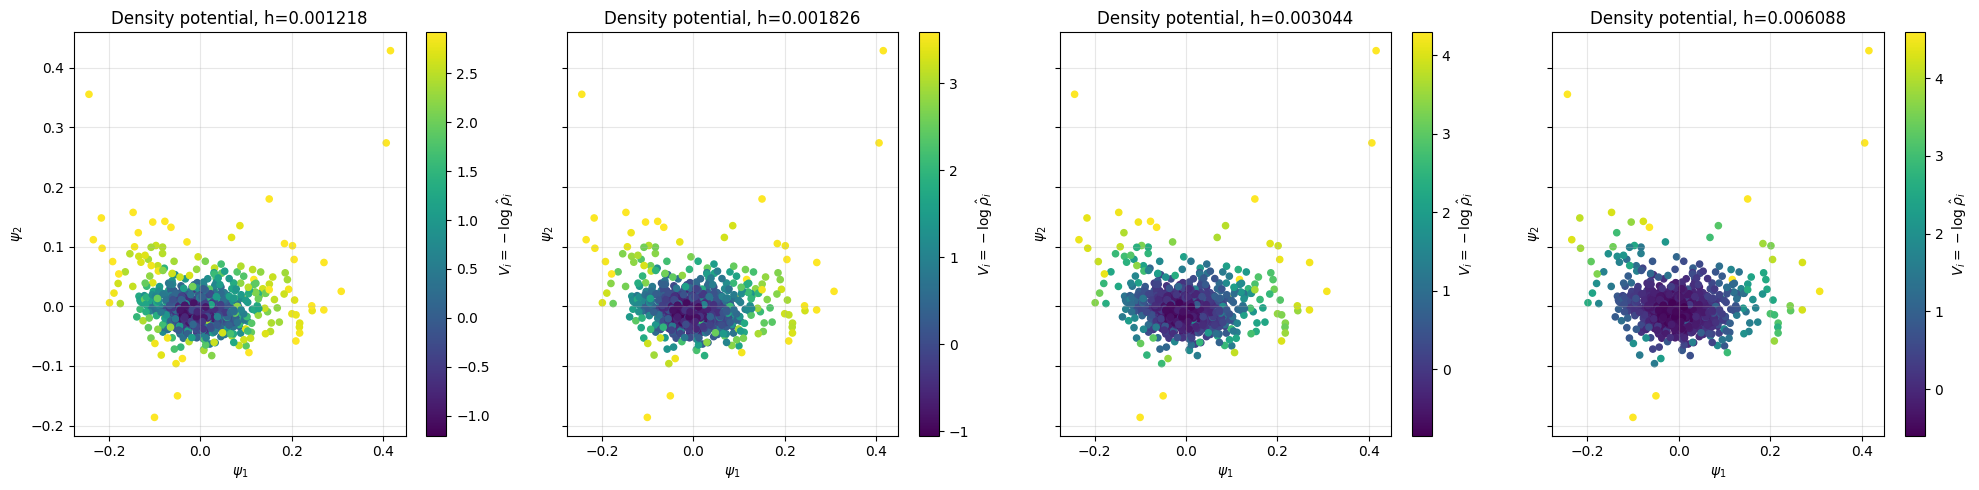

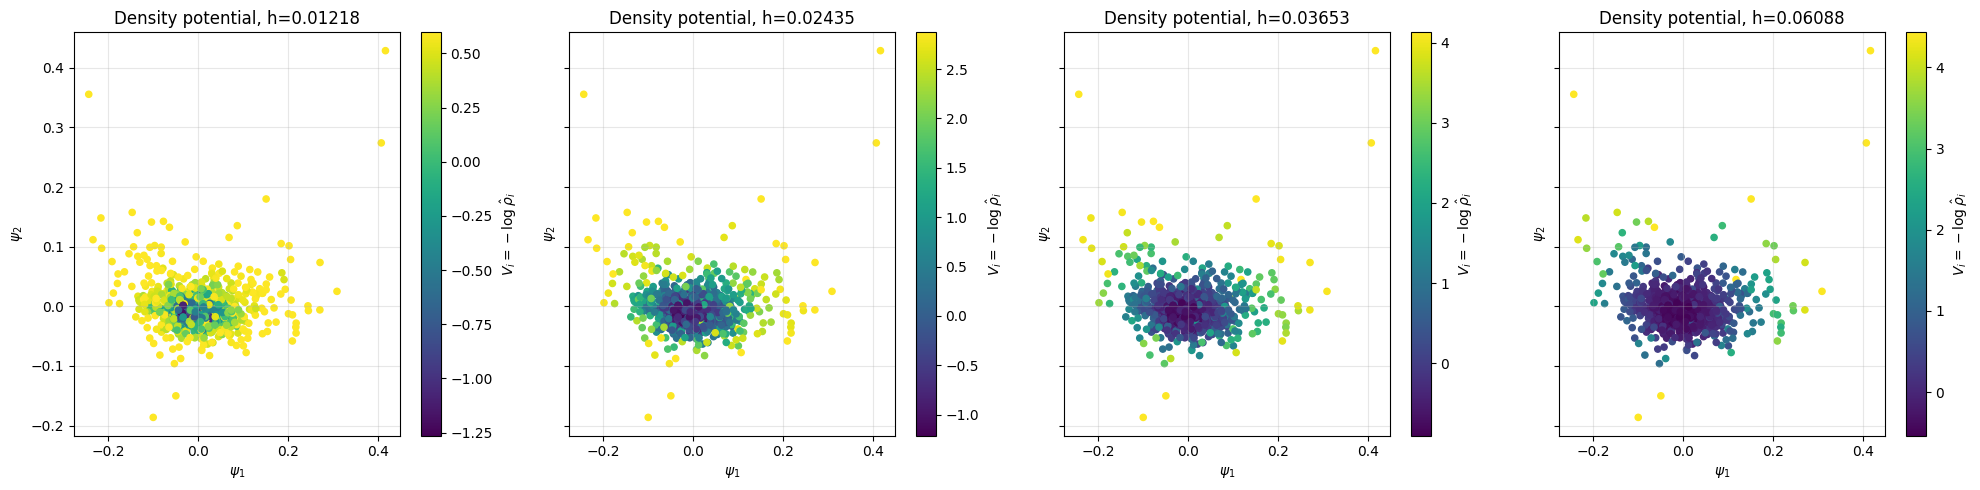

In [83]:
Dsq_Psi = squareform(pdist(Psi) ** 2)
median_Dsq = np.median(Dsq_Psi[Dsq_Psi > 0])

h_grid = median_Dsq * np.array([0.10, 0.15, 0.25, 0.5])

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
for h, ax in zip(h_grid, axes.ravel()):
    rho, V = graph_degree_density(Psi, h)
    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=V, s=20, cmap="viridis")
    fig.colorbar(sc, ax=ax, label=r"$V_i=-\log \hat\rho_i$")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.set_title(fr"Density potential, h={h:.4g}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

h_grid = median_Dsq * np.array([1.0, 2.0, 3.0, 5.0])
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
for h, ax in zip(h_grid, axes.ravel()):
    rho, V = KDE_density(Psi, h, r=8)
    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=V, s=20, cmap="viridis")
    fig.colorbar(sc, ax=ax, label=r"$V_i=-\log \hat\rho_i$")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")
    ax.set_title(fr"Density potential, h={h:.4g}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

I like the look of $h=0.001826$ for the graph degree density and $h=0.02435$ for the KDE density.

Moving forward I will only use the graph density estimate.


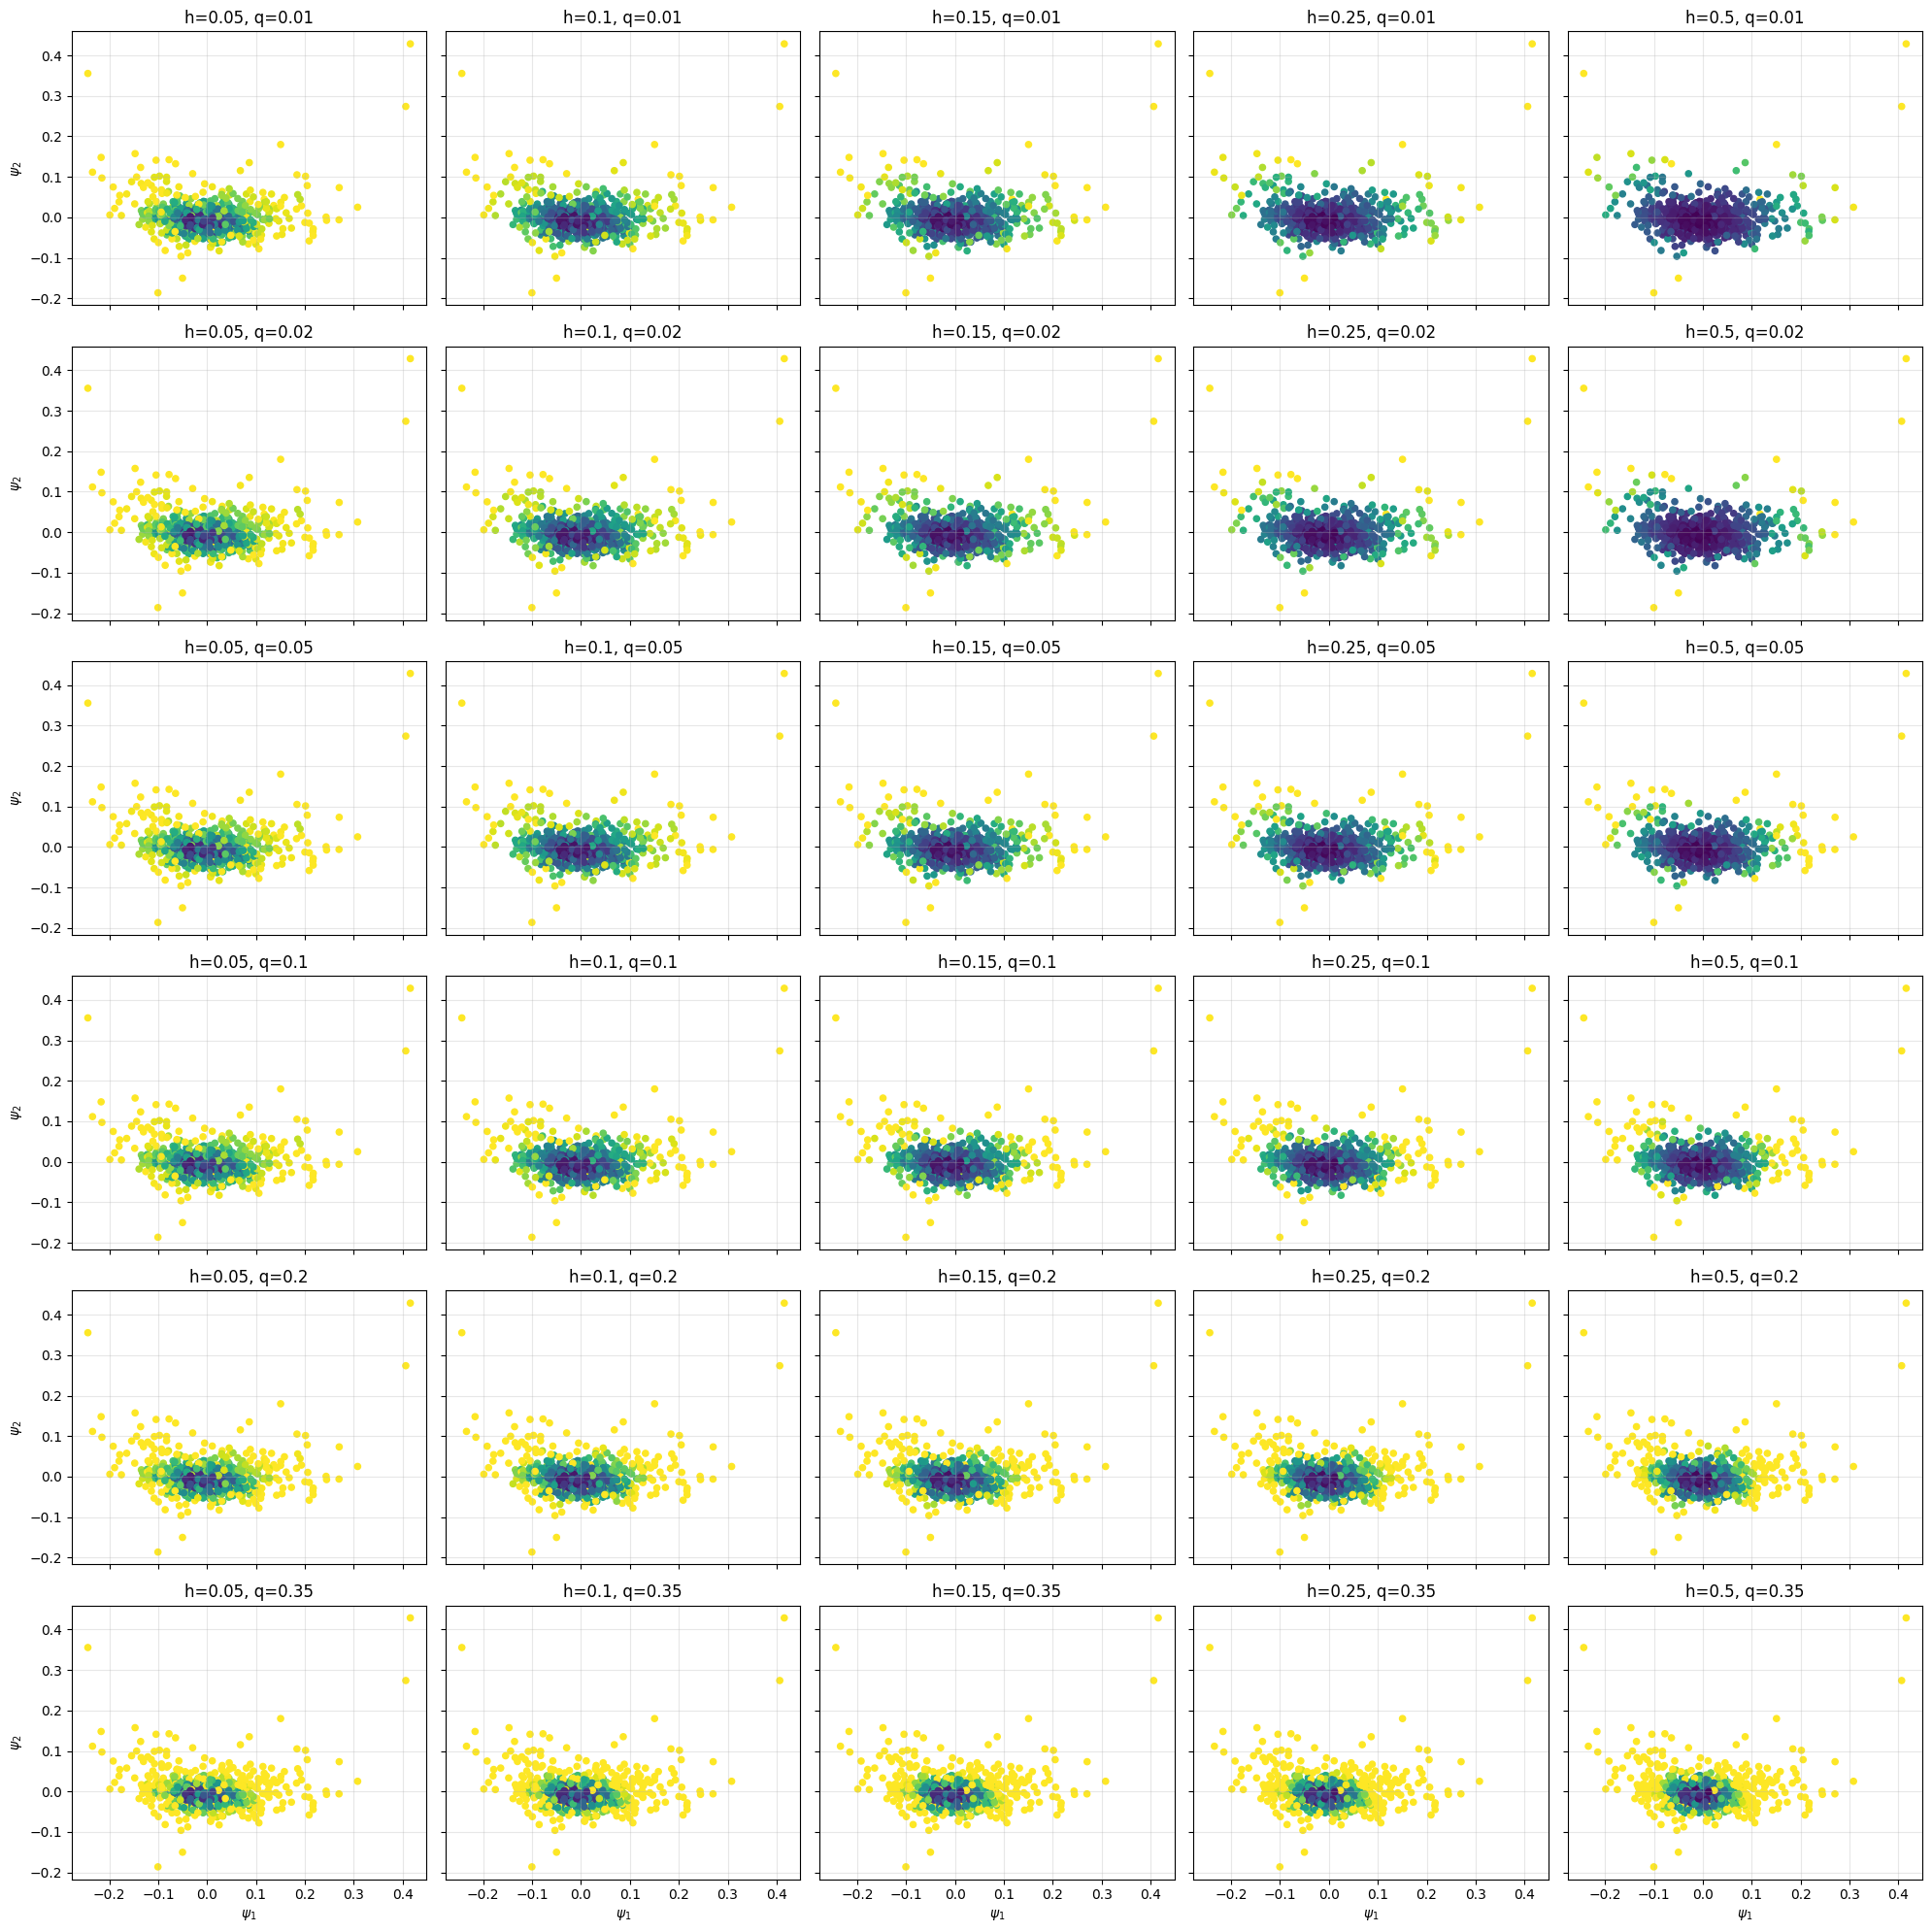

In [88]:
Dsq_Psi = squareform(pdist(Psi) ** 2)
median_Dsq = np.median(Dsq_Psi[Dsq_Psi > 0])

h_grid = np.array([0.05, 0.10, 0.15, 0.25, 0.5])
delta_quantiles = [0.01, 0.02, 0.05, 0.10, 0.20, 0.35]

fig, axes = plt.subplots(6, 5, figsize=(20, 20), sharex=True, sharey=True)
for (q, h), ax in zip(itertools.product(delta_quantiles, h_grid), axes.ravel()):
    Dh = median_Dsq * h
    rho, V = graph_degree_density(Psi, Dh, qtl=q)
    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=V, s=20, cmap="viridis")
    ax.set_title(fr"h={h:.4g}, q={q:.3g}")
    ax.grid(alpha=0.3)

for ax in axes[-1, :]:
    ax.set_xlabel(r"$\psi_1$")
for ax in axes[:, 0]:
    ax.set_ylabel(r"$\psi_2$")

plt.tight_layout()
plt.show()

I think for this data, $h\in (0.05, 0.15)$ and $q\in [0.01, 0.1)$ are good choices. There should be some fine tuning since depending on $h$ you may want a different $q$. The higher the $q$ (and therefore $\delta$), the more sudden the change in density is. The higher the badwidth $h$, the more points are 'closer together' from the perspective of the density function, so only very far away points are considered to be in regions of low density.

### Task 3.4: Density-aware graph cost

In [ ]:
def density_aware_cost_graph(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base_dist = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base_dist * np.exp(beta * (V[rows] + V[cols]) / 2)
    A_beta = csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)
    return A_beta

In [124]:
betas = [0, 0.25, 0.5, 0.75, 1, 2, 4]

# Create KNN adjacency matrix for our diffusion coordinates
A_dist = kneighbors_graph(Psi, n_neighbors=15, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Get a density potential vector for this embedding
rho, V = graph_degree_density(Psi, h=0.10*median_Dsq, qtl=0.02)

# Get the weight matrix w^(beta) for the cost of each path
A_beta_dict = {}
for beta in betas:
    A_beta_dict[beta] = density_aware_cost_graph(A_dist_sym, V, beta)

In [125]:
start = 680 # COVID
end = 290   # 1987 recession

betas = [0, 0.5, 1, 2, 4]

def path_edge_summary(A_cost, start, end):
    dist, pred = shortest_path(A_cost, directed=False, unweighted=False, return_predecessors=True)

    # Get shortest path between two indices in diffusion space
    path = reconstruct_path(pred, start, end)
    # Get the cost of each hop in the path
    edge_lengths = np.array([A_cost[path[t], path[t + 1]] for t in range(len(path) - 1)])

    return {
        "path": path,
        "n_edges": len(edge_lengths),
        "total_cost": edge_lengths.sum(),
        "max_edge_cost": edge_lengths.max(),
        "median_edge_cost": np.median(edge_lengths),
        "max_median_ratio": edge_lengths.max() / np.median(edge_lengths),
    }   


path_rows = []
for beta in betas:
    out = path_edge_summary(A_beta_dict[beta], start, end)
    path_rows.append({
        "beta": beta,
        "n_edges": out["n_edges"],
        "total_cost": out["total_cost"],
        "max_edge_cost": out["max_edge_cost"],
        "median_edge_cost": out["median_edge_cost"],
        "max_median_ratio": out["max_median_ratio"],
    })

path_df = pd.DataFrame(path_rows)
display(path_df)

,beta,n_edges,total_cost,max_edge_cost,median_edge_cost,max_median_ratio
0,0.0,9,1.016576,0.501231,0.061515,8.148121e+00
1,0.5,12,2.986589,1.876913,0.038948,4.819076e+01
2,1.0,12,10.016177,7.057142,0.037000,1.907332e+02
3,2.0,13,130.652598,99.769605,0.014954,6.671983e+03
4,4.0,14,24802.820467,19940.548080,0.004936,4.039714e+06


Now we can see that some edges are far more expensive than others for higher levels of $\beta$. 

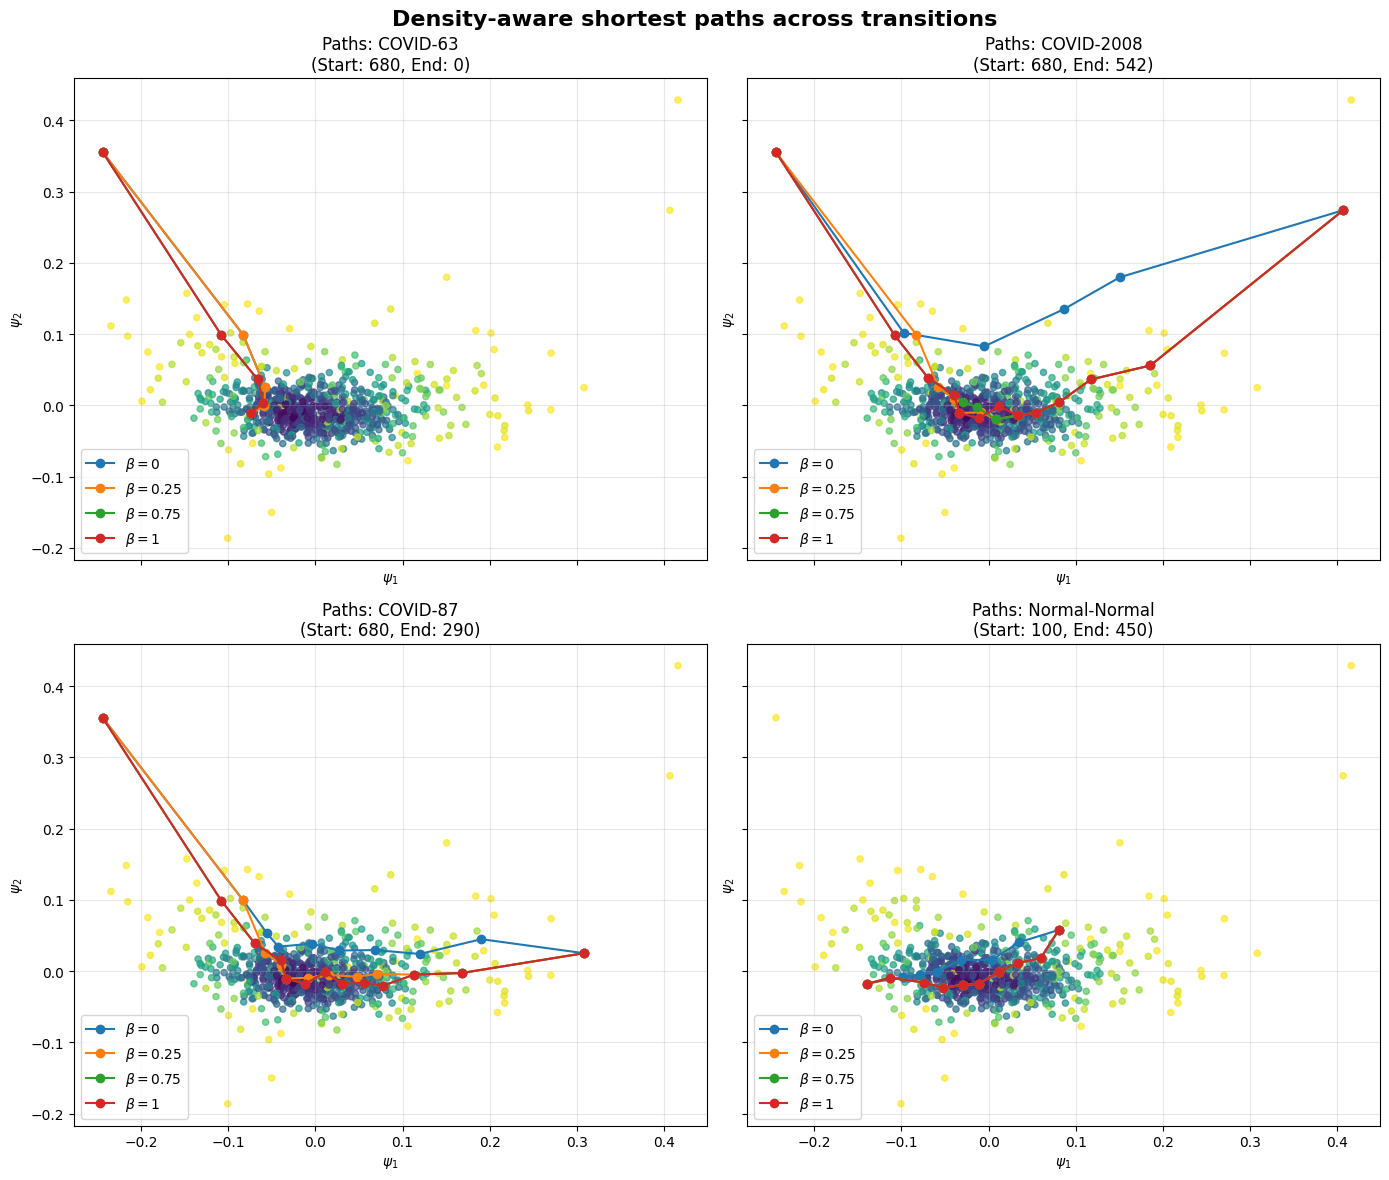

In [128]:
points = {"COVID-63": (680, 0), "COVID-2008": (680, 542), "COVID-87": (680, 290), "Normal-Normal": (100, 450)}
betas = [0, 0.25, 0.75, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, (name, (start, end)) in enumerate(points.items()):
    ax = axes[i]
    sc = ax.scatter(Psi[:, 0], Psi[:, 1], c=V, s=20, cmap="viridis", alpha=0.7)
    for beta in betas:
        path = path_edge_summary(A_beta_dict[beta], start, end)["path"]
        P = Psi[path]
        ax.plot(P[:, 0], P[:, 1], marker="o", label=rf"$\beta={beta}$")
    ax.set_xlabel(r"$\psi_1$"); ax.set_ylabel(r"$\psi_2$")
    ax.set_title(f"Paths: {name}\n(Start: {start}, End: {end})")
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Density-aware shortest paths across transitions", fontsize=16, weight="bold")
plt.tight_layout(); plt.show()


The cost is definitely working, for non-zero $\beta$ values, the 'shortest path' much prefers to go through high density regions. It seems as if even a small value of $\beta$ is enough to make the path change a lot. In that case, I would choose $\beta$ as the lowest value, here $\beta=0.25$, because I imagine that would be the most numerically stable.


### Phase 3 output


| Parameter | Explored Range / Value(s) |
| :--- | :--- |
| **Accepted $k$ values** | $5, 10, 15, 20, 30$ |
| **Density bandwidth** | $D^2_{\text{median}} \times [0.05, 0.15]$ |
| **Floor** | $\text{Quantile}(\rho, 0.01) - \text{Quantile}(\rho, 0.10)$ |
| **Beta values** | $(0, 1]$ |

